In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from astroquery.jplhorizons import Horizons
import warnings 
from erfa import ErfaWarning

warnings.filterwarnings('ignore', category=ErfaWarning, message='.*dubious year.*')

In [65]:
col = ['time', 'x', 'y', 'z', 'vx', 'vy', 'vz']

vec_earth = pd.read_csv('EARTH.aei', sep=r'\s+', skiprows=4, names=col)
vec_aa29 = pd.read_csv('2002AA29.aei', sep=r'\s+', skiprows=4, names=col)
vec_space = pd.read_csv('SPACECRAFT.aei', sep=r'\s+', skiprows=4, names=col)

x_earth, y_earth, z_earth = vec_earth['x'], vec_earth['y'], vec_earth['z']
x_aa29, y_aa29, z_aa29 = vec_aa29['x'], vec_aa29['y'], vec_aa29['z']
x_space, y_space, z_space = vec_space['x'], vec_space['y'], vec_space['z']

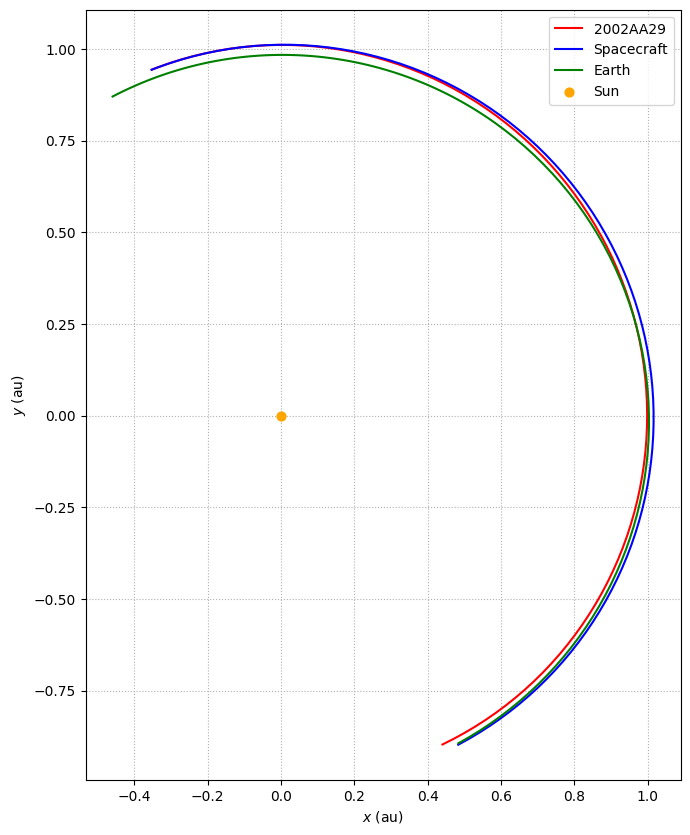

In [66]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(vec_aa29['x'], vec_aa29['y'],
         label='2002AA29', color='red', zorder=2)
ax.plot(vec_space['x'], vec_space['y'],
         label='Spacecraft', color='blue', zorder=3)
ax.plot(vec_earth['x'], vec_earth['y'],
         label='Earth', color='green', zorder=3)
ax.scatter(0, 0, label='Sun', color='orange', s=40, zorder=2)
ax.set_aspect('equal')
ax.set_xlabel('$x$ (au)')
ax.set_ylabel('$y$ (au)')
ax.legend()
ax.grid(True, linestyle=':')

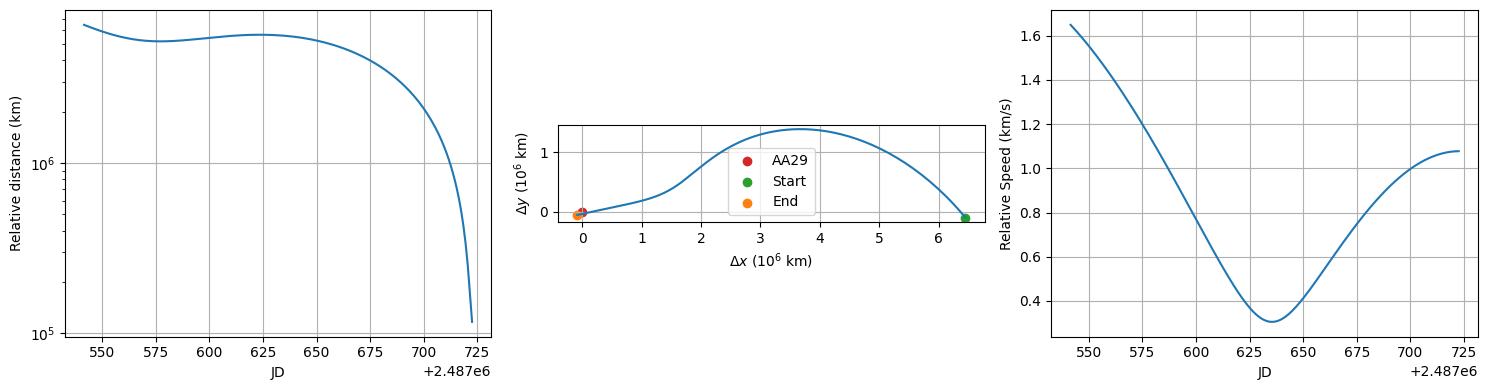

Final distance : 116,704.4 km
Minimum distance: 116,704.4 km
Final Δv       : 1.0777 km/s


In [67]:
AU_KM = 149_597_870.7
DAY_S = 86_400.0

df = (
    vec_space.merge(vec_aa29, on="time", suffixes=("_sc", "_aa29"))
    .sort_values("time")
)

dr_au = np.sqrt(
    (df["x_sc"] - df["x_aa29"])**2
    + (df["y_sc"] - df["y_aa29"])**2
    + (df["z_sc"] - df["z_aa29"])**2
)
dr_km = dr_au * AU_KM

dv_km_s = np.sqrt(
    (df["vx_sc"] - df["vx_aa29"])**2
    + (df["vy_sc"] - df["vy_aa29"])**2
    + (df["vz_sc"] - df["vz_aa29"])**2
) * AU_KM / DAY_S

dx_mkm = (df["x_sc"] - df["x_aa29"]) * AU_KM / 1e6
dy_mkm = (df["y_sc"] - df["y_aa29"]) * AU_KM / 1e6

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(df["time"], dr_km)
ax[0].set_yscale("log")
ax[0].set(xlabel="JD", ylabel="Relative distance (km)")
ax[0].grid()

ax[1].plot(dx_mkm, dy_mkm)
ax[1].scatter(0, 0, c="tab:red", label="AA29")
ax[1].scatter(dx_mkm.iloc[0], dy_mkm.iloc[0], c="tab:green", label="Start")
ax[1].scatter(dx_mkm.iloc[-1], dy_mkm.iloc[-1], c="tab:orange", label="End")
ax[1].set_aspect("equal")
ax[1].set(
    xlabel=r"$\Delta x$ ($10^6$ km)",
    ylabel=r"$\Delta y$ ($10^6$ km)",
)
ax[1].legend()
ax[1].grid()

ax[2].plot(df["time"], dv_km_s)
ax[2].set(xlabel="JD", ylabel=r"Relative Speed (km/s)")
ax[2].grid()

plt.tight_layout()
plt.show()

print(f"Final distance : {dr_km.iloc[-1]:,.1f} km")
print(f"Minimum distance: {dr_km.min():,.1f} km")
print(f"Final Δv       : {dv_km_s.iloc[-1]:.4f} km/s")

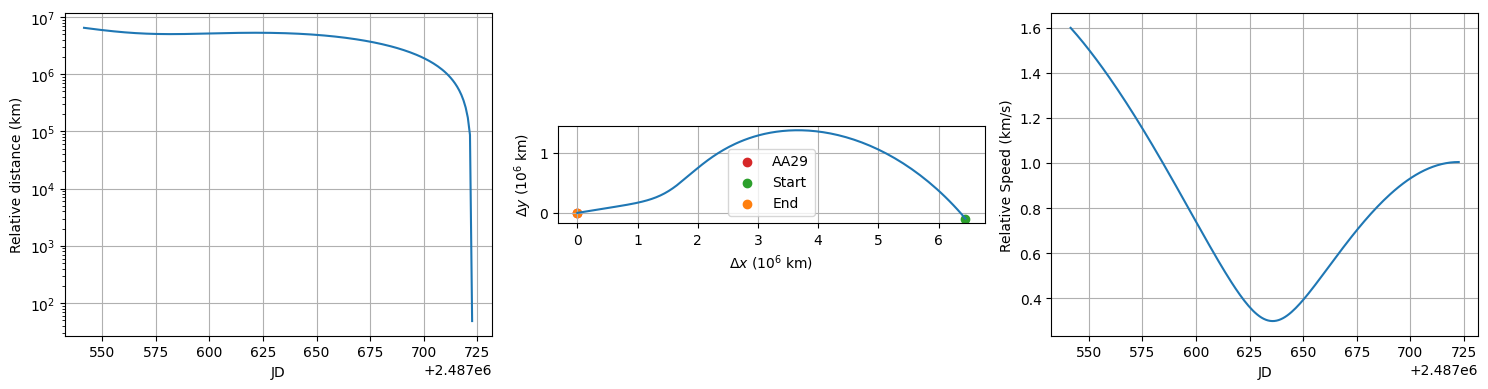

Final distance : 48.5 km
Minimum distance: 48.5 km
Final Δv       : 1.0048 km/s


In [68]:
vec_space_corrected = pd.read_csv('SPACECRAFT-run3.aei', sep=r'\s+', skiprows=4, names=col)
x_space_corrected, y_space_corrected, z_space_corrected = vec_space_corrected['x'], vec_space_corrected['y'], vec_space_corrected['z']

df = (
    vec_space_corrected.merge(vec_aa29, on="time", suffixes=("_sc", "_aa29"))
    .sort_values("time")
)

dr_au = np.sqrt(
    (df["x_sc"] - df["x_aa29"])**2
    + (df["y_sc"] - df["y_aa29"])**2
    + (df["z_sc"] - df["z_aa29"])**2
)
dr_km = dr_au * AU_KM

dv_km_s = np.sqrt(
    (df["vx_sc"] - df["vx_aa29"])**2
    + (df["vy_sc"] - df["vy_aa29"])**2
    + (df["vz_sc"] - df["vz_aa29"])**2
) * AU_KM / DAY_S

dx_mkm = (df["x_sc"] - df["x_aa29"]) * AU_KM / 1e6
dy_mkm = (df["y_sc"] - df["y_aa29"]) * AU_KM / 1e6

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(df["time"], dr_km)
ax[0].set_yscale("log")
ax[0].set(xlabel="JD", ylabel="Relative distance (km)")
ax[0].grid()

ax[1].plot(dx_mkm, dy_mkm)
ax[1].scatter(0, 0, c="tab:red", label="AA29")
ax[1].scatter(dx_mkm.iloc[0], dy_mkm.iloc[0], c="tab:green", label="Start")
ax[1].scatter(dx_mkm.iloc[-1], dy_mkm.iloc[-1], c="tab:orange", label="End")
ax[1].set_aspect("equal")
ax[1].set(
    xlabel=r"$\Delta x$ ($10^6$ km)",
    ylabel=r"$\Delta y$ ($10^6$ km)",
)
ax[1].legend()
ax[1].grid()

ax[2].plot(df["time"], dv_km_s)
ax[2].set(xlabel="JD", ylabel=r"Relative Speed (km/s)")
ax[2].grid()

plt.tight_layout()
plt.show()

print(f"Final distance : {dr_km.iloc[-1]:,.1f} km")
print(f"Minimum distance: {dr_km.min():,.1f} km")
print(f"Final Δv       : {dv_km_s.iloc[-1]:.4f} km/s")

In [69]:
ARR_JD = 2487722.5
DV_TEST = 1e-6  # AU/day

vec_space_vx = pd.read_csv('SPACECRAFT-vx.aei', sep=r'\s+', skiprows=4, names=col)
vec_space_vy = pd.read_csv('SPACECRAFT-vy.aei', sep=r'\s+', skiprows=4, names=col)
vec_space_vz = pd.read_csv('SPACECRAFT-vz.aei', sep=r'\s+', skiprows=4, names=col)

initial_velocity = np.array([
    0.0148363,
    0.0078598,
   -0.00248766,
])

def au_per_day_to_m_per_s(value):
    return np.asarray(value) * AU_KM * 1000 / DAY_S

def miss_vector(vec_sc, vec_aa29, arr_jd=ARR_JD):
    df = (
        vec_sc.merge(vec_aa29, on="time", suffixes=("_sc", "_aa29"))
        .sort_values("time")
    )

    row = df.loc[(df["time"] - arr_jd).abs().idxmin()]

    return np.array([
        row["x_sc"] - row["x_aa29"],
        row["y_sc"] - row["y_aa29"],
        row["z_sc"] - row["z_aa29"],
    ])

# --------------------------------------------------
# 1. 기준 실행과 vx/vy/vz 섭동 실행으로 J0 구성
# --------------------------------------------------

dr0 = miss_vector(vec_space, vec_aa29)
drx = miss_vector(vec_space_vx, vec_aa29)
dry = miss_vector(vec_space_vy, vec_aa29)
drz = miss_vector(vec_space_vz, vec_aa29)

J0 = np.column_stack([
    (drx - dr0) / DV_TEST,
    (dry - dr0) / DV_TEST,
    (drz - dr0) / DV_TEST,
])

dv1 = np.linalg.solve(J0, -dr0)
velocity_run2 = initial_velocity + dv1

print("Run 1 miss [km]:", dr0 * AU_KM)
print("First correction [m/s]:", au_per_day_to_m_per_s(dv1))
print("Run 2 velocity [AU/day]:", velocity_run2)

vec_space_run2 = pd.read_csv("SPACECRAFT-run2.aei", sep=r"\s+", skiprows=4, names=col,)

# --------------------------------------------------
# 2. Run 2 (약 4,547 km miss) 보정
# --------------------------------------------------

dr1 = miss_vector(vec_space_run2, vec_aa29)

# J0 재사용. 충분히 작아진 잔차에서는 대체로 잘 작동함.
dv2 = np.linalg.solve(J0, -dr1)
velocity_run3 = velocity_run2 + dv2

print("Run 2 miss [km]:", dr1 * AU_KM)
print("Second correction [m/s]:", au_per_day_to_m_per_s(dv2))
print("Run 3 velocity [AU/day]:", velocity_run3)
print(
    "Net correction [m/s]:",
    np.linalg.norm(au_per_day_to_m_per_s(velocity_run3 - initial_velocity)),
)

Run 1 miss [km]: [-80021.5892381809   -51593.649160560286  67487.45989412838 ]
First correction [m/s]: [ -8.616595770657057   -5.1086613602270035 -73.27580049888552  ]
Run 2 velocity [AU/day]: [ 0.0148313234995251  0.0078568495011763 -0.0025299803160144]
Run 2 miss [km]: [3139.477759593664  3173.1720652341114 -866.0352751804045]
Second correction [m/s]: [-0.0249525027642017 -0.0194057472420637  0.3976249817186392]
Run 3 velocity [AU/day]: [ 0.0148313090882489  0.0078568382934195 -0.0025297506683713]
Net correction [m/s]: 73.56766881947223
